# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [7]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/seo_dataset.csv")

# Create priority score
df["Priority_Score"] = (
    (100 - df["scroll_depth_percent"]) + # Lower scroll depth -> higher priority
    df["bounce_rate"] +                 # Higher bounce rate -> higher priority
    df["serp_position_before"] +        # Higher (worse) SERP position -> higher priority
    (1000 - df["content_length"]) / 100 + # Lower content length -> higher priority
    (100 - df["backlink_count"]) +     # Lower backlink count -> higher priority
    (-df["avg_time_on_page_sec"] / 10)  # Lower avg time on page -> higher priority (scaled)
)

# Reason codes
def reason_code(row):
    if row["scroll_depth_percent"] < 25:
        return "RC01" # Low engagement (scroll depth)
    elif row["bounce_rate"] > 70:
        return "RC02" # High bounce rate
    elif row["serp_position_before"] > 20:
        return "RC03" # Poor SERP position
    elif row["content_length"] < 800:
        return "RC04" # Short content
    elif row["backlink_count"] < 20:
        return "RC05" # Low backlinks
    else:
        return "RC06" # General improvement/other factors

df["Reason_Code"] = df.apply(reason_code, axis=1)

queue = df.sort_values(
    by="Priority_Score",
    ascending=False
)

queue.head(10)

,content_length,keyword_density,num_internal_links,num_external_links,has_meta_description,has_alt_text,avg_time_on_page_sec,bounce_rate,scroll_depth_percent,domain_authority,page_authority,backlink_count,serp_position_before,ranking_improved,Priority_Score,Reason_Code
139,1483,1.85,23,8,0,0,137,73.76,21.4,17,59,10,46,0,269.83,RC01
362,1415,1.44,31,13,0,1,57,67.98,20.5,49,86,6,30,0,261.63,RC01
212,486,2.90,17,10,1,0,71,77.15,39.7,73,68,8,32,0,259.49,RC02
290,2385,1.06,22,7,0,0,86,60.32,23.6,28,32,4,49,1,259.27,RC01
223,2143,1.61,34,13,0,1,124,76.12,37.3,15,64,6,49,0,257.99,RC02
480,414,1.17,29,8,0,1,98,66.38,33.9,41,51,14,43,0,257.54,RC03
205,593,0.86,48,5,1,1,124,52.44,27.6,57,12,9,48,1,255.51,RC03
24,1047,1.98,13,1,1,1,104,77.17,25.6,81,48,9,21,1,252.70,RC02
22,321,2.87,42,11,1,0,102,61.90,23.4,48,29,8,25,0,252.09,RC01
176,1436,3.35,18,12,0,1,122,71.03,24.4,79,80,13,35,0,252.07,RC01


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [8]:
print("Dataset Size:", len(df))
print("Action Queue Size:", len(queue))
print()

queue[["Priority_Score", "Reason_Code"]].describe()

Dataset Size: 500
Action Queue Size: 500



,Priority_Score
count,500.000000
mean,185.493760
std,32.141161
min,107.680000
25%,164.585000
50%,185.850000
75%,206.882500
max,269.830000


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [9]:
review_summary = queue["Reason_Code"].value_counts()

review_summary


,count
Reason_Code,
RC03,226
RC05,143
RC02,78
RC01,32
RC04,21


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

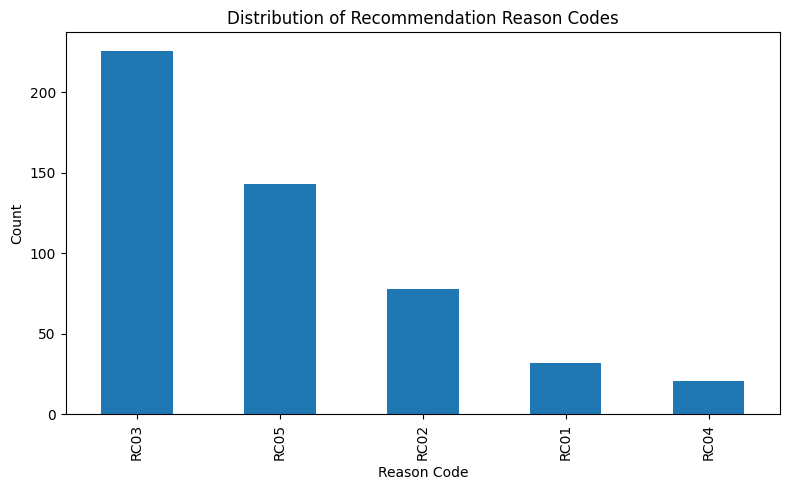

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

queue["Reason_Code"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Recommendation Reason Codes")
plt.xlabel("Reason Code")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os

os.makedirs("/content/work/outputs", exist_ok=True)
os.makedirs("/content/work/figures", exist_ok=True)

# Export queue
queue.to_csv(
    "/content/work/outputs/action_queue.csv",
    index=False
)

# Export figure
plt.figure(figsize=(8,5))

queue["Reason_Code"].value_counts().plot(kind="bar")

plt.title("Recommendation Reason Codes")

plt.tight_layout()

plt.savefig(
    "/content/work/figures/reason_codes.png"
)

plt.close()

print("Exports completed successfully.")

Exports completed successfully.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.